In [1]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('student_clustering.csv')
df.sample(5)

,cgpa,iq
43,5.31,86
101,5.01,86
167,5.15,85
38,5.44,84
176,8.94,115


In [4]:
df.shape

(200, 2)

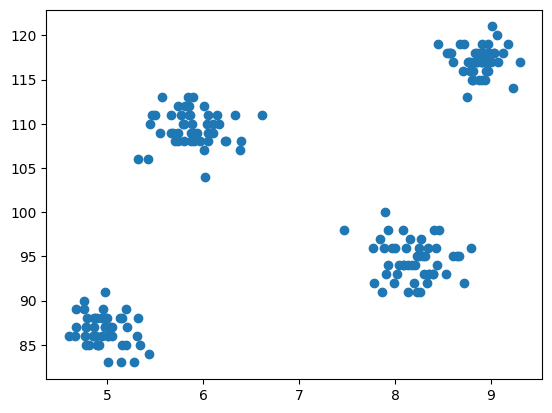

In [6]:
import matplotlib.pyplot as plt
plt.scatter(x=df['cgpa'], y=df['iq'])

In [7]:
from sklearn.cluster import KMeans

In [8]:
wcss = []
for i in range(1, 11):
  km = KMeans(n_clusters=i)
  km.fit_predict(df)
  wcss.append(km.inertia_)

In [9]:
wcss

[29957.898287999997,
 4184.141269999999,
 2503.3975810000015,
 681.9696600000001,
 530.4298616986187,
 449.65385575546657,
 354.6821372004185,
 317.12386648807177,
 234.36592037015782,
 175.12714854629027]

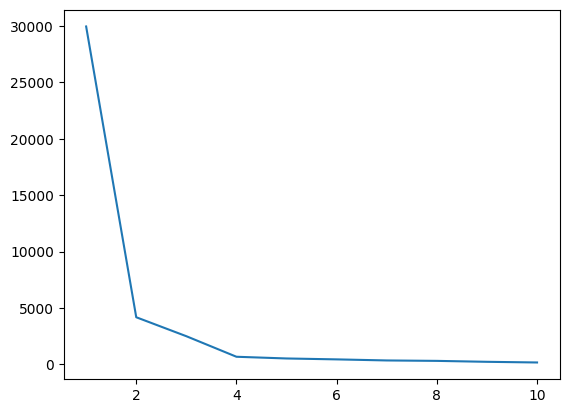

In [11]:
plt.plot(range(1,11), wcss)

In [12]:
X = df.iloc[:,:].values
km = KMeans(n_clusters=4)
y_means = km.fit_predict(X)

In [16]:
len(set(y_means))

4

In [17]:
y_means

array([1, 0, 3, 3, 0, 0, 3, 2, 0, 3, 1, 0, 3, 1, 0, 3, 0, 3, 0, 0, 3, 1,
       3, 1, 1, 3, 1, 2, 3, 0, 2, 0, 2, 0, 3, 3, 2, 0, 1, 0, 1, 3, 3, 1,
       2, 2, 3, 0, 2, 0, 1, 1, 2, 3, 2, 0, 0, 2, 0, 2, 0, 3, 3, 2, 1, 2,
       3, 1, 0, 3, 0, 2, 3, 1, 0, 2, 0, 2, 1, 3, 3, 2, 0, 1, 2, 1, 2, 0,
       2, 0, 2, 2, 3, 1, 3, 3, 2, 3, 1, 2, 0, 1, 1, 2, 1, 1, 3, 1, 2, 2,
       3, 2, 0, 0, 3, 2, 3, 0, 2, 1, 1, 0, 3, 2, 3, 1, 3, 0, 1, 3, 3, 0,
       1, 1, 0, 2, 0, 1, 3, 3, 3, 1, 0, 1, 1, 2, 1, 2, 0, 1, 2, 1, 2, 2,
       1, 3, 0, 2, 0, 3, 1, 2, 0, 3, 2, 1, 0, 1, 1, 2, 2, 0, 2, 1, 1, 3,
       2, 0, 1, 2, 2, 0, 0, 0, 3, 1, 3, 3, 2, 0, 3, 3, 1, 1, 3, 1, 2, 0,
       0, 2], dtype=int32)

In [18]:
# points belonging to cluster 0
zeroes = X[y_means == 0]

In [19]:
# points belonging to cluster 1
ones = X[y_means == 1]

In [20]:
# points belonging to cluster 2
twos = X[y_means == 2]

In [21]:
# points belonging to cluster 3
threes = X[y_means == 3]

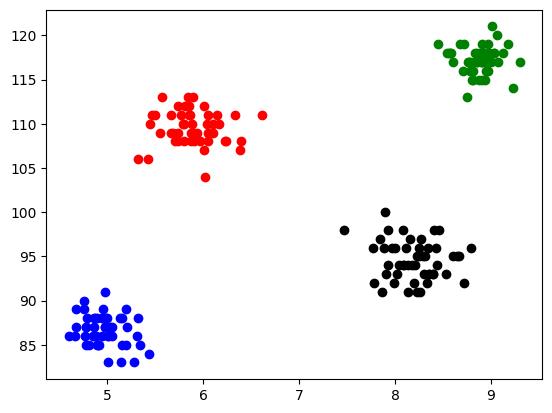

In [24]:
# plotting alll cluster with different clusters
plt.scatter(X[y_means == 0,0],X[y_means == 0,1], color='red')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1], color='blue')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1], color='green')
plt.scatter(X[y_means == 3,0],X[y_means == 3,1], color='black')


### K-Means on 3D data

In [25]:
from sklearn.datasets import make_blobs

centroids = [(-5,-5,5),(5,5,-5),(3.5,-2,4),(-2.5,2.5,-4)]
cluster_std = [1,1,1,1]

X,y = make_blobs(n_samples=200, cluster_std=cluster_std, centers=centroids, n_features=3, random_state=1)

In [28]:
import plotly.express as px
fig = px.scatter_3d(x=X[:,0], y=X[:,1], z=X[:,2])
fig.show()

In [34]:
wcss = []
for i in range (1,20):
  km = KMeans(n_clusters=i)
  km.fit_predict(X)
  wcss.append(km.inertia_)

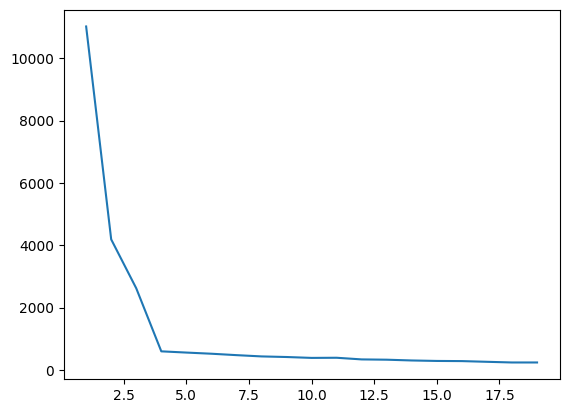

In [35]:
plt.plot(range(1,20),wcss)

In [36]:
km = KMeans(n_clusters=4)
y_pred = km.fit_predict(X)

In [37]:
df = pd.DataFrame()

df['col1'] = X[:,0]
df['col2'] = X[:,1]
df['col3'] = X[:,2]
df['label'] = y_pred

In [38]:
fig = px.scatter_3d(df, x='col1', y='col2',z='col3',color='label')
fig